In [1]:
from models import *
from brian2 import *

import sys, os
import pickle as pk
import numpy as np
import pandas as pd
from itertools import product
import matplotlib.pyplot as plt
from rich import print as rprint
from multiprocessing import Pool

from utils import *

sys.path.append("../")
from sangrah.tools import get_info

sys.path.append('../../scripts_analysis')
from analysis import *

simTypes = {
    'control':     dict(d='control', r='result.dat', v='vesData.dat'),
    'without cross-talk': dict(d='control_eachCa', r='sresult_RRP_{}.dat', v='svesData_RRP_{}.dat'),
    'syt7KO':      dict(d='syt7KO', r='result.dat', v='vesData.dat'),
    'nonsatBuffer': dict(d='control_unsatBuffer', r='result.dat', v='vesData.dat')
}

dataPath = "../../data"

In [15]:
category_info_path = os.path.join(dataPath, 'control_eachCa/category_info.pk')
if os.path.exists(category_info_path):
    with open(category_info_path, "rb") as infile:
        category_info = pk.load(infile)

# rprint(category_info[0,0,0,0]['rep_design_median'])

categories = []
for category in category_info.ravel():
    # rprint(category)
    if category:
        categories.append(str(category['rep_design_median']))

# len(categories), categories

In [3]:
dirs = [a for a in getDirs(os.path.join(dataPath, 'control'), sstr='nVDCC') if "ISI_20" in a]
dirs.sort(key=natural_keys)
control_dirs = np.array(dirs)

for i,d in enumerate(control_dirs): print(i, d)

0 nVDCC_1_dVAZ_60_nAZ_33_RRP_55_ISI_20_nAP_10
1 nVDCC_1_dVAZ_60_nAZ_33_RRP_60_ISI_20_nAP_10
2 nVDCC_2_dVAZ_60_nAZ_7_RRP_60_ISI_20_nAP_10
3 nVDCC_2_dVAZ_60_nAZ_9_RRP_55_ISI_20_nAP_10
4 nVDCC_2_dVAZ_60_nAZ_9_RRP_60_ISI_20_nAP_10
5 nVDCC_2_dVAZ_60_nAZ_11_RRP_40_ISI_20_nAP_10
6 nVDCC_2_dVAZ_60_nAZ_11_RRP_45_ISI_20_nAP_10
7 nVDCC_2_dVAZ_60_nAZ_11_RRP_50_ISI_20_nAP_10
8 nVDCC_2_dVAZ_60_nAZ_13_RRP_35_ISI_20_nAP_10
9 nVDCC_2_dVAZ_60_nAZ_13_RRP_40_ISI_20_nAP_10
10 nVDCC_2_dVAZ_60_nAZ_13_RRP_45_ISI_20_nAP_10
11 nVDCC_2_dVAZ_60_nAZ_13_RRP_50_ISI_20_nAP_10
12 nVDCC_2_dVAZ_60_nAZ_15_RRP_30_ISI_20_nAP_10
13 nVDCC_2_dVAZ_60_nAZ_15_RRP_35_ISI_20_nAP_10
14 nVDCC_2_dVAZ_60_nAZ_17_RRP_30_ISI_20_nAP_10
15 nVDCC_2_dVAZ_60_nAZ_19_RRP_30_ISI_20_nAP_10
16 nVDCC_2_dVAZ_60_nAZ_21_RRP_20_ISI_20_nAP_10
17 nVDCC_2_dVAZ_60_nAZ_21_RRP_25_ISI_20_nAP_10
18 nVDCC_2_dVAZ_60_nAZ_23_RRP_20_ISI_20_nAP_10
19 nVDCC_2_dVAZ_60_nAZ_23_RRP_25_ISI_20_nAP_10
20 nVDCC_2_dVAZ_60_nAZ_25_RRP_20_ISI_20_nAP_10
21 nVDCC_2_dVAZ_60_nAZ_27_

In [4]:
def run_sim(nMFB, spid, sptimes, tstep=0.1):
    defaultclock.dt = tstep*ms
    start_scope()

    MFBvrel = SpikeGeneratorGroup(nMFB, spid, sptimes*ms)

    nCA3p = nMFB
    CA3p = NeuronGroup(nCA3p, eqnCA3_PR, 
                    # method='exponential_euler', 
                    method='euler', 
                    threshold='Vs>0*mV', 
                    refractory='Vs>0*mV', 
                    namespace=CA3p_PR_params)
    CA3p.Vd = -61.3 * mV
    CA3p.Vs = -61.2 * mV

    # Synapse: MFB to CA3 pyramidal neuron
    MFB_CA3p_syn = Synapses(MFBvrel, CA3p,
                            model=eqs_MFB_CA3p_syn,
                            on_pre=MFB_CA3p_onpre,
                            # method='exponential_euler',
                            method='euler',
                            namespace=MFB_CA3p_syn_params)
    MFB_CA3p_syn.connect(j='i')

    # Monitors
    stMCA3p = StateMonitor(CA3p, ['Vd', 'Vs', 'Iampa', 'Inmda'], record=True)
    spMCA3p = SpikeMonitor(CA3p)

    # Run the simulation
    run(1210 * ms)

    return stMCA3p, spMCA3p

In [5]:
## Get MFB vesicle release times
tstep=0.01
design = categories[34]
# design = control_dirs[1253]
simType = 'control'
print(design)

simInfo = get_info(design, skip=0)

if simType == 'without cross-talk':
    design = design.split('RRP')[0] + 'ISI' + design.split('ISI')[1]
resultDir = os.path.join(dataPath, simTypes[simType]['d'], design)
RRP = simInfo['RRP']
# print(design, RRP)

# ves_data_file = 'vesData.dat' if simType == 'control' else 'svesData.dat'

# print(simTypes[simType]['v'].format(RRP))
inf = os.path.join(resultDir, simTypes[simType]['v'].format(RRP))
with open(inf, "rb") as infile:
    vesData = pk.load(infile)
    # print(vesData.keys())
    
if simType == 'control':
    vrel_times = [[(1+float(val))*1000 for val in vals] for vals in vesData[RRP]]
    # vrel_times = vrel_times[:50] ##### For testing
else:
    seeds = len(vesData['AZ1']['sync'])
    vrel_times = [[] for _ in range(seeds)]
    for i in range(seeds):
        for az in list(vesData.keys()):
            for k in vesData[az].keys():
                vrel_times[i] += [(1+float(a))*1000 for a in vesData[az][k][i]] # Convert to ms

vrel_times = [np.sort(v) for v in vrel_times]
# print(vrel_times)

nMFB, spid, sptimes = get_spike_generator_info(vrel_times[:2000])
# print(nMFB, np.array(spid), np.array(sptimes))


nVDCC_6_dVAZ_200_nAZ_29_RRP_50_ISI_20_nAP_10


In [6]:
MFB_CA3p_syn_params['g_AMPA'] = 0.2*mS
MFB_CA3p_syn_params['g_NMDA'] = 0.5*mS
MFB_CA3p_syn_params['tau_AMPA'] = 2*ms # 2*ms
CA3p_PR_params['Gc'] = 10*mS
CA3p_PR_params['p'] = 0.75
CA3p_PR_params['noise'] = 3*uA
CA3p_PR_params['Isapp'] = -0.5*uA
CA3p_PR_params['Gkahp'] = 0.8*mS # 0.8*mS
CA3p_PR_params['Gkca'] = 15*mS # 15.0*mS
CA3p_PR_params['Gkdr'] = 15*mS # 15.0*mS

In [7]:
# print(f"Running simulation for: {design}")
stMCA3p, spMCA3p = run_sim(nMFB, spid, sptimes, tstep=tstep)
# test_plot(stMCA3p, spMCA3p, vrel_times)

# ## Spike times of CA3p
# CA3p_spikes = [np.sort([t-1000 for t in (a/ms).tolist() if t>1000]) for a in 
#                 spMCA3p.spike_trains().values()]

# ## Synaptic currents
# epscs = -stMCA3p.Iampa[:,int(1000/tstep):]/uA

# ## timepoints
# tt = stMCA3p.t[int(1000/tstep):]/ms - 1000

WARNING    'i' is an internal variable of group 'synapses', but also exists in the run namespace with the value 1410. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


In [8]:
def _getAPprob(apTimes, tc=20, nAP=10, trim=1000):
    seeds = len(apTimes)
    # print(apTimes[:10])

    ## Stimulus times
    stimTimes = np.sort([1.5 + na*20 for na in range(nAP)])
    # print(stimTimes)
    
    ## AP probability
    apProb = np.zeros(nAP)
    for apts in apTimes:
        temp = np.zeros(nAP)
        for apt in apts:
            for i,st in enumerate(stimTimes):
                if np.ceil((st+tc-apt)/tc)==1:
                    temp[i] = 1
        apProb += temp
    apProb /= seeds

    ## probability of 1st AP
    ap1Prob = np.zeros(nAP)
    for apts in apTimes:
        # print(apts)
        temp = np.zeros(nAP)
        for i,st in enumerate(stimTimes):
            try:
                if np.ceil((st+tc-apts[0])/tc)==1:
                    temp[i] = 1
            except IndexError:
                continue
        ap1Prob += temp
    # print(ap1Prob)
    ap1Prob /= seeds
    
    return apProb, ap1Prob

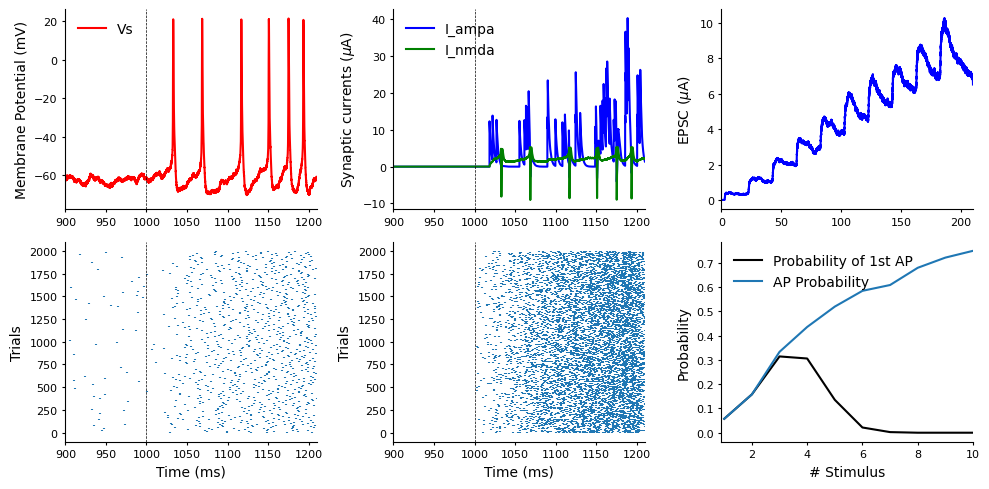

In [9]:
def test_plot(stMCA3p, spMCA3p, vrel_times):
    fig, axs = plt.subplots(2,3, figsize=(10, 5), sharex=False)
    fig.subplots_adjust(wspace=0.1, hspace=0.1)
    # fig.suptitle("Simulation Results")

    ## Plot the CA3 spikes
    # axs[0,0].plot(stMCA3p.t/ms, stMCA3p.Vd[0]/mV, 'b-', label='Vd')
    axs[0,0].plot(stMCA3p.t/ms, stMCA3p.Vs[0]/mV, 'r-', label='Vs')
    axs[1,0].set_xlabel("Time (ms)")
    axs[0,0].set_ylabel("Membrane Potential (mV)")
    axs[0,0].legend(frameon=False)

    ## Plot the synaptic current
    axs[0,1].plot(stMCA3p.t/ms, -stMCA3p.Iampa[0]/uA, 'b-', label='I_ampa')
    axs[0,1].plot(stMCA3p.t/ms, -stMCA3p.Inmda[0]/uA, 'g-', label='I_nmda')
    axs[1,1].set_xlabel("Time (ms)")
    axs[0,1].set_ylabel(r"Synaptic currents ($\mu$A)")
    axs[0,1].legend(frameon=False)

    ## Raster plot of the CA3 spikes
    CA3p_sptimes = [a/ms for a in spMCA3p.spike_trains().values()]
    # axs[1,0].plot(spMCA3p.t/ms, spMCA3p.i, 'k.', markersize=2)
    axs[1,0].eventplot(CA3p_sptimes)
    axs[1,0].set_ylabel("Trials")

    ## Raster plot of the MFB vesicle releases
    axs[1,1].eventplot(vrel_times)
    axs[1,1].set_ylabel("Trials")

    ## Synaptic currents
    epscs = -stMCA3p.Iampa[:,int(1000/tstep):]/uA
    tt = stMCA3p.t[int(1000/tstep):]/ms - 1000
    axs[0,2].plot(tt, np.mean(epscs, axis=0), 'b-', label='EPSC')
    axs[0,2].set_ylabel(r"EPSC ($\mu$A)")
    # axs[0,2].legend(frameon=False)

    ## AP probability
    nAP = 10
    apProb, ap1Prob = _getAPprob([np.sort([t-1000 for t in (a).tolist() if t>1000]) for a in CA3p_sptimes])
    axs[1,2].plot(range(1, nAP+1), ap1Prob, color='black', label='Probability of 1st AP')
    axs[1,2].plot(range(1,11), apProb, label='AP Probability')
    axs[1,2].set_ylabel("Probability")
    axs[1,2].legend(frameon=False)

    axs[1,2].set_xlabel("# Stimulus")
    for ax in axs.ravel():
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.tick_params(axis=u'both', which=u'both', length=2, labelsize=8)
        ax.set_xlim(900, 1210)
        ax.axvline(x=1000, color='black', linestyle='--', linewidth=0.5)

    axs[0,2].set_xlim(0, 210)
    axs[1,2].set_xlim(0.9,10)
    plt.tight_layout()
    plt.show()

test_plot(stMCA3p, spMCA3p, vrel_times)

In [10]:
vrel_times[0][0:3]

array([1018.45, 1022.2 , 1027.05])

In [11]:
CA3p_sptimes = [a/ms for a in spMCA3p.spike_trains().values()]
trials = len(CA3p_sptimes)
CA3p_sptimes[0:3]

[array([  63.83,  192.43,  541.58,  802.75, 1032.74, 1068.4 , 1116.7 ,
        1150.64, 1174.9 , 1193.23]),
 array([  87.34,  249.87,  387.79,  681.86, 1028.52, 1098.77, 1129.06,
        1149.17, 1173.22, 1203.6 ]),
 array([ 149.99,  312.37,  562.98, 1063.26, 1117.53, 1147.83, 1172.54,
        1197.34])]

In [12]:
rel_to_ap = []
for tr in list(range(trials)):
    sptime = CA3p_sptimes[tr][0]
    vrel = vrel_times[tr ] - 1000
    rel_to_ap.append(int(np.sum(vrel < sptime)))

np.mean(rel_to_ap), np.std(rel_to_ap)

(np.float64(12.3115), np.float64(16.04971861902881))